In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

In [6]:
# Read in labels
labels = pd.read_csv(Path("/Users/miguelibarra/PycharmProjects/cin/labels/test_balanced.csv"))

In [7]:
# Check value counts
labels.label.value_counts()

label
0    402
1    402
Name: count, dtype: int64

In [9]:
# Check value counts
labels["count"].value_counts()

count
0    402
1    360
2     33
3      8
4      1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='count'>

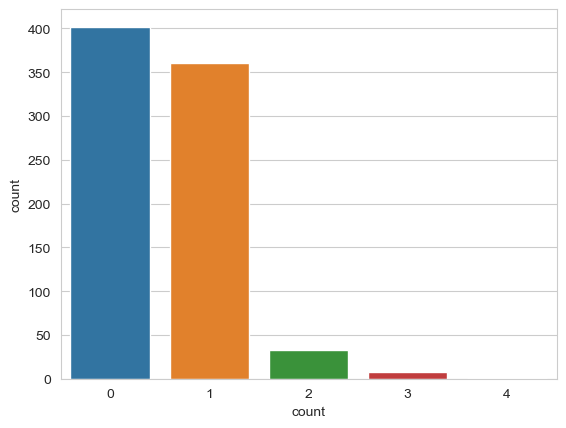

In [13]:
# Plot barplot with the data distribution
sns.barplot(x=labels["count"].value_counts().index, y=labels["count"].value_counts())

In [12]:
# Binarize between has cin and doesnt have cin
labels["has_cin"] = (labels["label"]>0).astype(int)

In [15]:
labels.to_csv(Path("/Users/miguelibarra/PycharmProjects/cin/labels/labels_miguel_20230313_cin.csv"), index=False)

# Check some other shit

In [15]:
predictions=pd.read_csv(Path("/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/week3/predictions/stardist/s01c1_predictions.csv"))
predictions["has_cin"] = (predictions["score"]>0.5).astype(int)
predictions["has_cin"].value_counts()

has_cin
0    1542
1     295
Name: count, dtype: int64

In [257]:
# Getting predictions by well
predictions["well"] = predictions.image.apply(lambda x: "_".join(x.split("_")[:-1]))

In [106]:
for i, g in predictions.groupby("well"):
    print(i)
    print(g["has_cin"].value_counts())

12621_redo_brain_mets_nsclc_images_s04
0    3453
1    1209
Name: has_cin, dtype: int64
12621_redo_brain_mets_nsclc_images_s05
0    2809
1     977
Name: has_cin, dtype: int64
12621_redo_brain_mets_nsclc_images_s06
0    3464
1    1057
Name: has_cin, dtype: int64
brain_mets_and_lung_cancer_basal_micronuclei_s13
0    449
1    133
Name: has_cin, dtype: int64
brain_mets_and_lung_cancer_basal_micronuclei_s14
0    553
1     94
Name: has_cin, dtype: int64
brain_mets_and_lung_cancer_basal_micronuclei_s15
0    513
1    100
Name: has_cin, dtype: int64
cell_lines_master_plate-Stitching-01_s09
0    1883
1     892
Name: has_cin, dtype: int64
cell_lines_master_plate-Stitching-01_s10
0    2983
Name: has_cin, dtype: int64
cell_lines_master_plate-Stitching-01_s11
0    3443
Name: has_cin, dtype: int64
cell_lines_master_plate-Stitching-01_s12
0    3047
Name: has_cin, dtype: int64
lkb1KO_recon_autofocus-Stitching-09_s01
0    1293
1     601
Name: has_cin, dtype: int64
lkb1KO_recon_autofocus-Stitching-09_s02


In [268]:
# Copy only the ones that were predicted to have a mn
src = Path("/Users/miguelibarra/PycharmProjects/cin/data/multiple_micronuclei/isonuc/cellpose2_fv20_s0.7_xms60_yms60_")
dst = Path("/Users/miguelibarra/PycharmProjects/micronuclei_labeling_tool/data")

for i, r in predictions[predictions["well"]=="cell_lines_master_plate-Stitching-01_s09"].iterrows():
    if r.has_cin==1:
        shutil.copy(src.joinpath(r.image), dst.joinpath(r.image))
    else:
        continue

In [120]:
# Read and display images with micronuclei
from skimage.io import imread
folder = Path("../data/multiple_micronuclei/isonuc/cellpose__fv20_s0.7_xms60_yms60_")
multi_s14 = predictions[predictions["well"]=="lkb1KO_recon_autofocus-Stitching-09_s06"]
# for i, j in multi_s14[multi_s14["has_cin"]==1].iterrows():
#     img = imread(folder.joinpath(j.image).resolve())
#     plt.matshow(img, cmap="gray_r")

In [108]:
# Read s14 lables
multi_s14_labels = pd.read_csv(Path("../data/multiple_micronuclei/labels/labels_miguel_multi_s14.csv").resolve())
multi_s14_labels["has_cin"] = (multi_s14_labels["count"]>0).astype(int)
multi_s14_labels["has_cin"].value_counts()

0    561
1     86
Name: has_cin, dtype: int64

In [109]:
multi_s14["has_cin"].value_counts()

0    553
1     94
Name: has_cin, dtype: int64

In [110]:
from sklearn.metrics import roc_auc_score, roc_curve

In [111]:
# Merge predictions with ground trues on a single df
results = pd.merge(multi_s14, multi_s14_labels, on="image")
results

,image,prediction,has_cin_x,well,count,has_cin_y
0,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.000223,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
1,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.000008,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
2,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.002036,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
3,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.043055,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
4,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.005038,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
...,...,...,...,...,...,...
642,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.000049,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
643,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.999499,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,1,1
644,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.999944,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,1,1
645,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.002048,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0


In [112]:
# Calculate AUC
auc = roc_auc_score(results["has_cin_y"], results["prediction"])
print("AUC:", auc)

AUC: 0.993947684782158


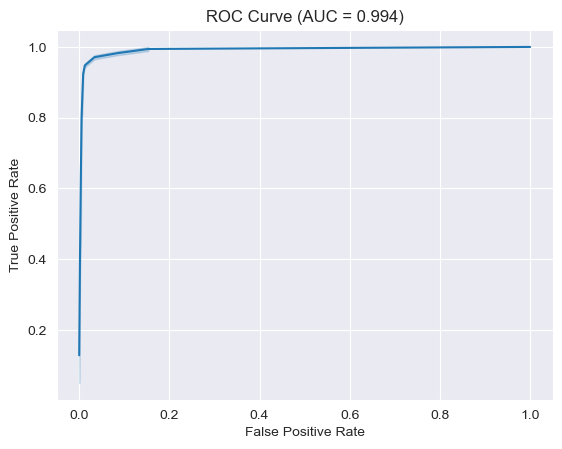

In [113]:
fpr, tpr, thresholds = roc_curve(results["has_cin_y"], results["prediction"])
sns.lineplot(x=fpr, y=tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = {:.3f})".format(auc))
plt.show()

In [114]:
results[results["has_cin_y"] != results["has_cin_x"]]

,image,prediction,has_cin_x,well,count,has_cin_y
14,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.009381,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,1,1
23,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.650127,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
45,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.988252,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
101,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.606183,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
174,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.994116,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
192,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.633065,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
226,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.893614,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
279,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.999879,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
325,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.999456,1,brain_mets_and_lung_cancer_basal_micronuclei_s14,0,0
348,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.192307,0,brain_mets_and_lung_cancer_basal_micronuclei_s14,2,1


0 1
0 1
0 1
0 1


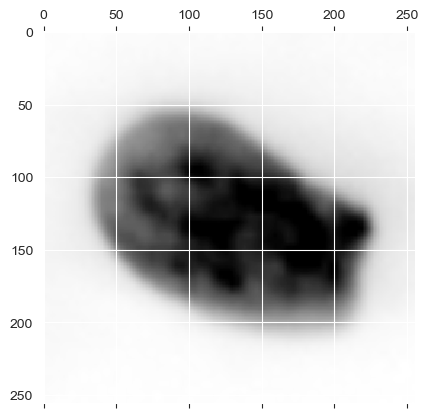

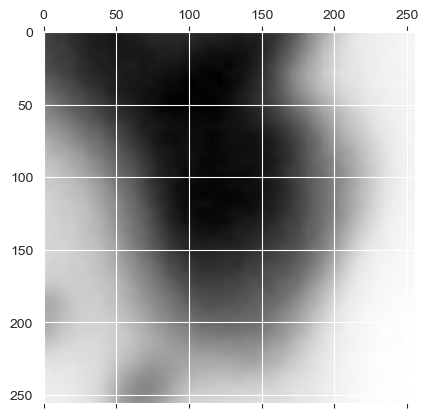

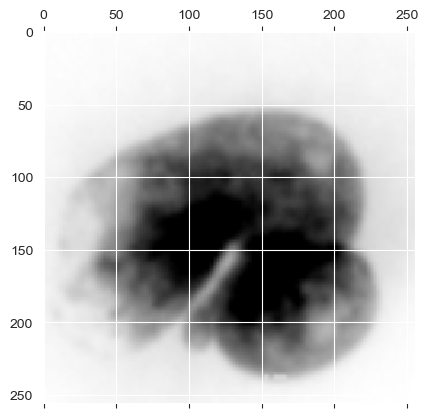

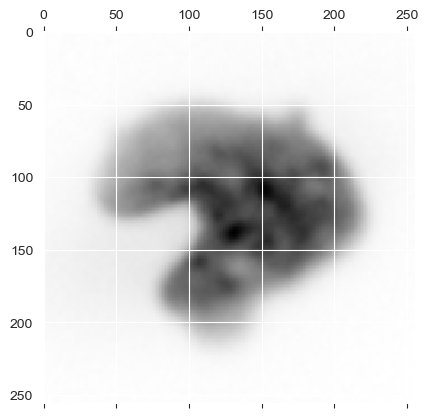

In [121]:
for i, j in results[results["has_cin_x"] < results["has_cin_y"]].iterrows():
    print(j.has_cin_x, j.has_cin_y)
    img = imread(folder.joinpath(j.image).resolve())
    plt.matshow(img, cmap="gray_r")

# Check results from counting

In [246]:
number_class = pd.read_csv(Path("../new_model4/test/test_predictions_0.csv").resolve())
number_class["rounded"].sum()

153

In [248]:
number_class.shape[0]

529

In [244]:
(number_class["targets"].sum()-number_class["rounded"].sum())/number_class["targets"].sum()

-0.224

/var/folders/9c/s912yv1x3dn6xwpfnggf8wt80000gn/T/ipykernel_34085/1312003970.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


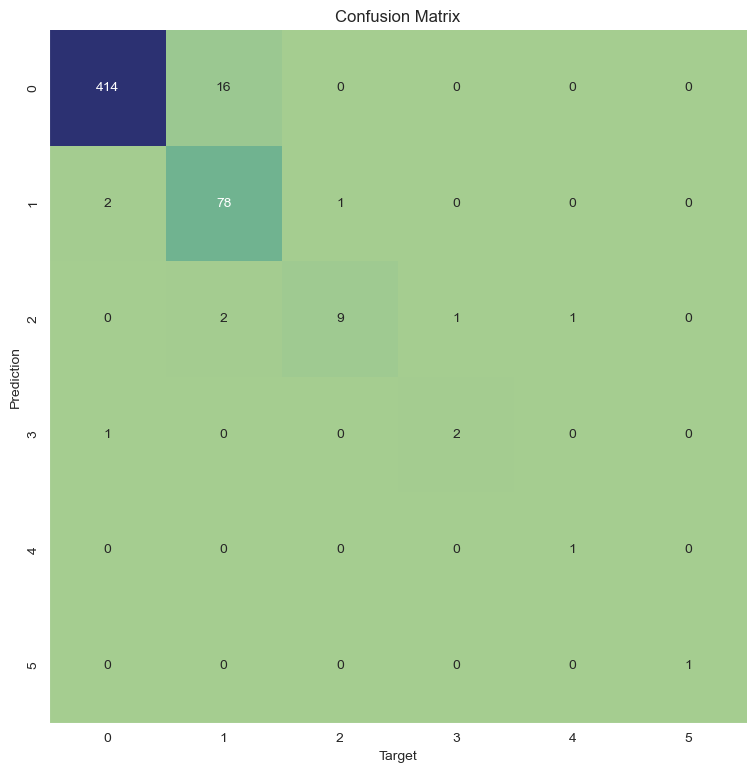

In [228]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(number_class["target"], number_class["rounded_0"])
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="crest", cbar=False, ax=ax)
ax.set_xlabel("Target")
ax.set_ylabel("Prediction")
ax.set_title("Confusion Matrix")
sns.despine()
fig.show()

In [229]:
acc = accuracy_score(number_class["target"], number_class["rounded_0"])
print(f"ACC = {acc}")

ACC = 0.9546313799621928


In [235]:
f1 = f1_score(number_class["target"], number_class["rounded_0"], average="weighted")
print(f"F1 = {f1}")

F1 = 0.9557364867332734


In [230]:
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, balanced_accuracy_score, f1_score

# Check counting predictions

In [249]:
# Read data
count_class = pd.read_csv(Path("../data/multiple_micronuclei/prediction/cellpose2_fv20_s0.7_xms60_yms60__predictions.csv"))
count_class.head()

,image,prediction
0,12621_redo_brain_mets_nsclc_images_s04_2605.png,0.133227
1,lkb1KO_recon_autofocus-Stitching-09_s01_725.png,0.445408
2,12621_redo_brain_mets_nsclc_images_s06_2871.png,0.115094
3,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.460864
4,12621_redo_brain_mets_nsclc_images_s04_286.png,0.553513


In [253]:
# Round predictions
count_class["rounded"] = count_class["prediction"].round().astype(int)

In [254]:
count_class

,image,prediction,rounded
0,12621_redo_brain_mets_nsclc_images_s04_2605.png,0.133227,0
1,lkb1KO_recon_autofocus-Stitching-09_s01_725.png,0.445408,0
2,12621_redo_brain_mets_nsclc_images_s06_2871.png,0.115094,0
3,brain_mets_and_lung_cancer_basal_micronuclei_s...,0.460864,0
4,12621_redo_brain_mets_nsclc_images_s04_286.png,0.553513,1
...,...,...,...
38983,12621_redo_brain_mets_nsclc_images_s04_3502.png,0.059191,0
38984,lkb1KO_recon_autofocus-Stitching-09_s03_1146.png,-0.028748,0
38985,12621_redo_brain_mets_nsclc_images_s05_1467.png,-0.059555,0
38986,12621_redo_brain_mets_nsclc_images_s06_2868.png,-0.089361,0
